In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import pickle
from datetime import datetime
import statsmodels.formula.api as smf

In [6]:
# load data
data = pd.read_csv('../data/subset.csv')

In [7]:
print(data.columns.tolist())

['country', 'date', 'new_cases_smoothed_per_million', 'population_density', 'median_age', 'gdp_per_capita', 'hospital_beds_per_thousand', 'life_expectancy', 'stringency_index', 'new_people_vaccinated_smoothed_per_hundred']


Create lagging and weekly aggregation

In [8]:
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['country', 'date'])

# lagging
data['vac_lag'] = (
    data.groupby('country')['new_people_vaccinated_smoothed_per_hundred']
        .shift(14)
        .fillna(0)
)

data['stringency_lag'] = (
    data.groupby('country')['stringency_index']
        .shift(7)
)

# drop only early rows
data = data.dropna(subset=['stringency_lag'])

# weekly aggregation
weekly = (
    data.groupby(['country', pd.Grouper(key='date', freq='W-MON')])
      .agg({
          'new_cases_smoothed_per_million': 'sum',

          # time-varying covariates
          'stringency_index': 'mean',
          'stringency_lag': 'mean',
          'new_people_vaccinated_smoothed_per_hundred': 'sum',
          'vac_lag': 'sum',

          # static covariates
          'population_density': 'first',
          'median_age': 'first',
          'gdp_per_capita': 'first',
          'hospital_beds_per_thousand': 'first',
          'life_expectancy': 'first'
      })
      .reset_index()
)

In [9]:
print(weekly.info)

<bound method DataFrame.info of            country       date  new_cases_smoothed_per_million  \
0      Afghanistan 2020-01-13                        0.000000   
1      Afghanistan 2020-01-20                        0.000000   
2      Afghanistan 2020-01-27                        0.000000   
3      Afghanistan 2020-02-03                        0.000000   
4      Afghanistan 2020-02-10                        0.000000   
...            ...        ...                             ...   
14999     Zimbabwe 2022-04-25                       15.637859   
15000     Zimbabwe 2022-05-02                       20.420786   
15001     Zimbabwe 2022-05-09                       16.882487   
15002     Zimbabwe 2022-05-16                       54.514698   
15003     Zimbabwe 2022-05-23                       28.715342   

       stringency_index  stringency_lag  \
0              0.000000        0.000000   
1              0.000000        0.000000   
2              0.000000        0.000000   
3              

Justify log transformation

For each country, we bin the data by quantile, compute the mean and variance within each bin, and then generate a plot demonstrating the mean-variance relationship.

In [10]:
df = weekly.copy()

results = []

for country, sub in df.groupby('country'):
    
    x = sub['new_cases_smoothed_per_million']
    
    if len(x) < 30:
        continue
    
    try:
        bins = pd.qcut(x, q=5, duplicates='drop')
    except ValueError:
        continue
    
    grouped = sub.groupby(bins)['new_cases_smoothed_per_million']
    
    means = grouped.mean()
    vars_ = grouped.var()
    
    for m, v in zip(means, vars_):
        if pd.notna(m) and pd.notna(v):
            results.append((country, m, v))

res_df = pd.DataFrame(results, columns=['country', 'mean', 'variance'])

/var/folders/8y/3c251v6s30g9t4vwff__270m0000gn/T/ipykernel_88590/2221922369.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby(bins)['new_cases_smoothed_per_million']


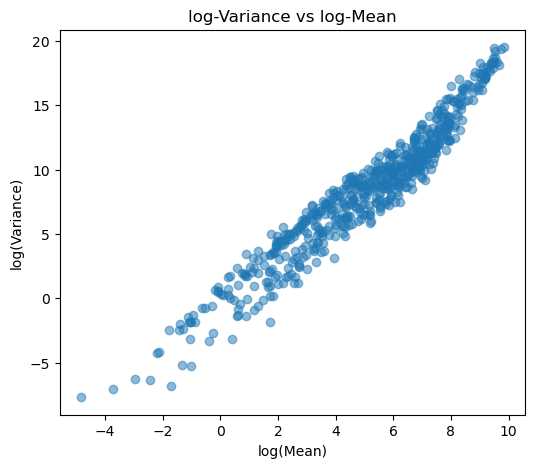

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(np.log(res_df['mean']), np.log(res_df['variance']), alpha=0.5)
plt.xlabel("log(Mean)")
plt.ylabel("log(Variance)")
plt.title("log-Variance vs log-Mean")
plt.show()

Log transformation

In [12]:
df = df.copy()

df['log_cases'] = np.log(df['new_cases_smoothed_per_million'] + 1) # make sure log-transformation is well-defined

In [13]:
results_log = []

for country, sub in df.groupby('country'):
    
    x = sub['log_cases']
    
    if len(x) < 30:
        continue
    
    try:
        bins = pd.qcut(x, q=5, duplicates='drop')
    except ValueError:
        continue
    
    grouped = sub.groupby(bins)['log_cases']
    
    means = grouped.mean()
    vars_ = grouped.var()
    
    for m, v in zip(means, vars_):
        if pd.notna(m) and pd.notna(v):
            results_log.append((country, m, v))

res_log_df = pd.DataFrame(results_log, columns=['country', 'mean', 'variance'])

/var/folders/8y/3c251v6s30g9t4vwff__270m0000gn/T/ipykernel_88590/546204797.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby(bins)['log_cases']


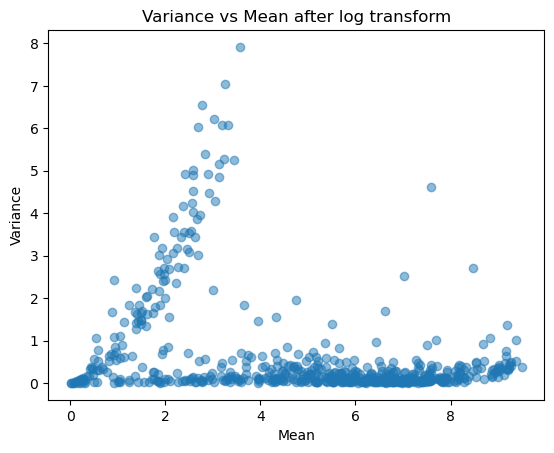

In [14]:
plt.scatter(res_log_df['mean'], res_log_df['variance'], alpha=0.5)
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("Variance vs Mean after log transform")
plt.show()

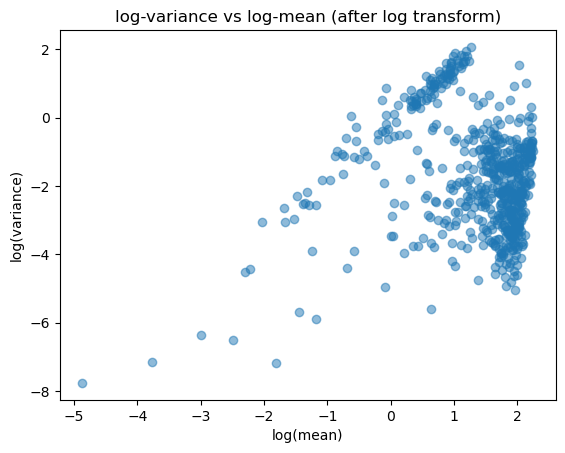

In [15]:
plt.scatter(
    np.log(res_log_df['mean'] + 1e-6), 
    np.log(res_log_df['variance'] + 1e-6), 
    alpha=0.5
)
plt.xlabel("log(mean)")
plt.ylabel("log(variance)")
plt.title("log-variance vs log-mean (after log transform)")
plt.show()

Log transform of the covariates with heavy right tail

In [16]:
for col in ['population_density', 'gdp_per_capita', 'hospital_beds_per_thousand']:
    df[col] = np.log(df[col])
    df = df.rename(columns={col: 'log_' + col})

Append continent info

In [17]:
# Generated by ChatGPT
country_to_continent = {
    'Afghanistan': 'Asia',
    'Albania': 'Europe',
    'Algeria': 'Africa',
    'Antigua and Barbuda': 'North America',
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Azerbaijan': 'Asia',
    'Bahamas': 'North America',
    'Bahrain': 'Asia',
    'Bangladesh': 'Asia',
    'Barbados': 'North America',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Belize': 'North America',
    'Bhutan': 'Asia',
    'Bolivia': 'South America',
    'Bosnia and Herzegovina': 'Europe',
    'Brazil': 'South America',
    'Brunei': 'Asia',
    'Bulgaria': 'Europe',
    'Burundi': 'Africa',
    'Cambodia': 'Asia',
    'Canada': 'North America',
    'Central African Republic': 'Africa',
    'Chile': 'South America',
    'China': 'Asia',
    'Colombia': 'South America',
    'Costa Rica': 'North America',
    'Croatia': 'Europe',
    'Cyprus': 'Europe',
    'Czechia': 'Europe',
    'Denmark': 'Europe',
    'Djibouti': 'Africa',
    'Dominica': 'North America',
    'Dominican Republic': 'North America',
    'Ecuador': 'South America',
    'Egypt': 'Africa',
    'El Salvador': 'North America',
    'Estonia': 'Europe',
    'Eswatini': 'Africa',
    'Ethiopia': 'Africa',
    'Fiji': 'Oceania',
    'Finland': 'Europe',
    'France': 'Europe',
    'Gambia': 'Africa',
    'Georgia': 'Asia',
    'Germany': 'Europe',
    'Ghana': 'Africa',
    'Greece': 'Europe',
    'Grenada': 'North America',
    'Guatemala': 'North America',
    'Guinea': 'Africa',
    'Guyana': 'South America',
    'Haiti': 'North America',
    'Honduras': 'North America',
    'Hungary': 'Europe',
    'Iceland': 'Europe',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Iran': 'Asia',
    'Iraq': 'Asia',
    'Ireland': 'Europe',
    'Israel': 'Asia',
    'Italy': 'Europe',
    'Jamaica': 'North America',
    'Japan': 'Asia',
    'Jordan': 'Asia',
    'Kazakhstan': 'Asia',
    'Kiribati': 'Oceania',
    'Kuwait': 'Asia',
    'Kyrgyzstan': 'Asia',
    'Laos': 'Asia',
    'Latvia': 'Europe',
    'Lebanon': 'Asia',
    'Libya': 'Africa',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Malawi': 'Africa',
    'Malaysia': 'Asia',
    'Malta': 'Europe',
    'Mauritius': 'Africa',
    'Mexico': 'North America',
    'Moldova': 'Europe',
    'Mongolia': 'Asia',
    'Montenegro': 'Europe',
    'Morocco': 'Africa',
    'Mozambique': 'Africa',
    'Myanmar': 'Asia',
    'Nepal': 'Asia',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Nicaragua': 'North America',
    'Niger': 'Africa',
    'North Macedonia': 'Europe',
    'Norway': 'Europe',
    'Oman': 'Asia',
    'Pakistan': 'Asia',
    'Panama': 'North America',
    'Paraguay': 'South America',
    'Peru': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Qatar': 'Asia',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America',
    'San Marino': 'Europe',
    'Sao Tome and Principe': 'Africa',
    'Saudi Arabia': 'Asia',
    'Serbia': 'Europe',
    'Seychelles': 'Africa',
    'Singapore': 'Asia',
    'Slovakia': 'Europe',
    'Slovenia': 'Europe',
    'Solomon Islands': 'Oceania',
    'Somalia': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sri Lanka': 'Asia',
    'Sudan': 'Africa',
    'Suriname': 'South America',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Tajikistan': 'Asia',
    'Togo': 'Africa',
    'Trinidad and Tobago': 'North America',
    'Tunisia': 'Africa',
    'Turkey': 'Asia',
    'Turkmenistan': 'Asia',
    'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia',
    'United Kingdom': 'Europe',
    'United States': 'North America',
    'Uruguay': 'South America',
    'Uzbekistan': 'Asia',
    'Vietnam': 'Asia',
    'Zimbabwe': 'Africa'
}

df['continent'] = df['country'].apply(lambda country: country_to_continent[country])

Create PC score

In [20]:
df_countries = df.drop_duplicates(subset = 'country', keep = 'last').copy()
X = np.array(df_countries[['log_population_density', 'median_age', 'log_gdp_per_capita', 'log_hospital_beds_per_thousand', 'life_expectancy']])
# Generated by ChatGPT
X_std = (X - X.mean(axis = 0)) / X.std(axis = 0, ddof = 1)

U, S, Vt = np.linalg.svd(X_std, full_matrices=False)

# Print PC loadings
features = ['log_population_density', 'median_age', 'log_gdp_per_capita', 
            'log_hospital_beds_per_thousand', 'life_expectancy']

loadings = pd.DataFrame(
    Vt[:2].T,
    index=features,
    columns=['PC1', 'PC2']
)
print("PC Loadings (how each variable is weighted):")
print(loadings.round(3))

PC Loadings (how each variable is weighted):
                                  PC1    PC2
log_population_density          0.060 -0.958
median_age                      0.527  0.036
log_gdp_per_capita              0.519  0.037
log_hospital_beds_per_thousand  0.466  0.222
life_expectancy                 0.483 -0.174


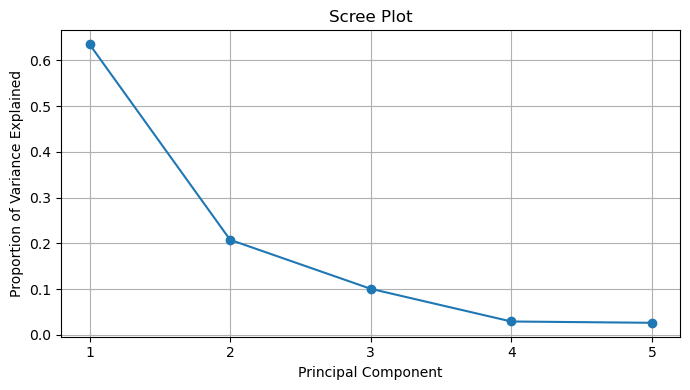

In [19]:
variance_explained = S**2 / np.sum(S**2)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(S)+1), variance_explained, 'o-')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.xticks(range(1, len(S)+1))
plt.grid(True)
plt.tight_layout()
plt.show()

Choose 2 PC

In [67]:
PCs = X_std @ Vt[:2].T
df_countries['pc1'] = PCs[:, 0]
df_countries['pc2'] = PCs[:, 1]

# standardize
for col in ['pc1', 'pc2']:
    df_countries[col] = (
        (df_countries[col] - df_countries[col].mean()) 
        / df_countries[col].std()
    )
    
# merge
df = df.merge(
    df_countries[['country', 'pc1', 'pc2']],
    on='country',
    how='left'
)

Create seaonal/monthly grouping

In [68]:
# helper function
def make_groups(dates, freq):
    if freq == 'monthly':
        return dates.to_period('M')

    elif freq == 'seasonal':
        month = dates.month.values
        year = dates.year.values
        
        season = np.empty(len(month), dtype=object)
        season[np.isin(month, [12, 1, 2])] = 'winter'
        season[np.isin(month, [3, 4, 5])]  = 'spring'
        season[np.isin(month, [6, 7, 8])]  = 'summer'
        season[np.isin(month, [9, 10, 11])] = 'fall'
        
        return pd.Series(year.astype(str) + '_' + season.astype(str))

    else:
        raise ValueError(f"Unsupported freq: {freq}")

# grouping
df['stringency_lag'] /= 100.0 # normalization
df['log_vac_lag'] = np.log1p(df['vac_lag']) # account for diminishing marginal effects of immunity on transmission
df = df.sort_values(['country', 'date']).reset_index(drop=True).copy()

df['time_block'] = make_groups(pd.DatetimeIndex(df['date']), freq='seasonal') # TODO: change

block_cov = (
    df
    .groupby(['country', 'time_block'])
    .agg(stringency_lag=('stringency_lag', 'mean'),
         vac_lag=('vac_lag', 'mean'),
         log_vac_lag=('log_vac_lag', 'mean'))
)

# standardize
block_cov = (block_cov - block_cov.mean()) / block_cov.std()

In [69]:
df = df[['country', 'date', 'log_cases', 'continent', 'pc1', 'pc2', 'time_block']]

Save preprocessed data

In [70]:
df.to_csv('../data/covid.csv', index=False)

# save block-level covariates (MultiIndex: country × time_block)
block_cov.reset_index().to_csv('../data/block_cov.csv', index=False)

In [71]:
print(block_cov.columns.tolist())

['stringency_lag', 'vac_lag', 'log_vac_lag']
